# Uber Ride Bookings Analysis

## 1. Setup

In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings

In [2]:
warnings.filterwarnings("ignore")

In [3]:
pd.set_option("display.max_columns", None)

In [4]:
sns.set_style('darkgrid')

## 2. Dataset Overview

In [5]:
uber_df = pd.read_csv('../ncr_ride_bookings.csv')
uber_df

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,NaN,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,NaN,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,NaN,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,NaN,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,2024-11-11,19:34:01,"""CNR6500631""",Completed,"""CID4337371""",Go Mini,MG Road,Ghitorni,10.2,44.4,NaN,NaN,NaN,NaN,NaN,NaN,475.0,40.08,3.7,4.1,Uber Wallet
149996,2024-11-24,15:55:09,"""CNR2468611""",Completed,"""CID2325623""",Go Mini,Golf Course Road,Akshardham,5.1,30.8,NaN,NaN,NaN,NaN,NaN,NaN,1093.0,21.31,4.8,5.0,UPI
149997,2024-09-18,10:55:15,"""CNR6358306""",Completed,"""CID9925486""",Go Sedan,Satguru Ram Singh Marg,Jor Bagh,2.7,23.4,NaN,NaN,NaN,NaN,NaN,NaN,852.0,15.93,3.9,4.4,Cash
149998,2024-10-05,07:53:34,"""CNR3030099""",Completed,"""CID9415487""",Auto,Ghaziabad,Saidulajab,6.9,39.6,NaN,NaN,NaN,NaN,NaN,NaN,333.0,45.54,4.1,3.7,UPI


In [6]:
uber_df.shape

(150000, 21)

## 3. Data Cleaning

### 3.1. Missing Values

In [7]:
uber_df.isna().sum()

Date                                      0
Time                                      0
Booking ID                                0
Booking Status                            0
Customer ID                               0
Vehicle Type                              0
Pickup Location                           0
Drop Location                             0
Avg VTAT                              10500
Avg CTAT                              48000
Cancelled Rides by Customer          139500
Reason for cancelling by Customer    139500
Cancelled Rides by Driver            123000
Driver Cancellation Reason           123000
Incomplete Rides                     141000
Incomplete Rides Reason              141000
Booking Value                         48000
Ride Distance                         48000
Driver Ratings                        57000
Customer Rating                       57000
Payment Method                        48000
dtype: int64

In [8]:
uber_df[uber_df.isna().any(axis=1)]

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,NaN,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,NaN,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,NaN,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,NaN,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,2024-11-11,19:34:01,"""CNR6500631""",Completed,"""CID4337371""",Go Mini,MG Road,Ghitorni,10.2,44.4,NaN,NaN,NaN,NaN,NaN,NaN,475.0,40.08,3.7,4.1,Uber Wallet
149996,2024-11-24,15:55:09,"""CNR2468611""",Completed,"""CID2325623""",Go Mini,Golf Course Road,Akshardham,5.1,30.8,NaN,NaN,NaN,NaN,NaN,NaN,1093.0,21.31,4.8,5.0,UPI
149997,2024-09-18,10:55:15,"""CNR6358306""",Completed,"""CID9925486""",Go Sedan,Satguru Ram Singh Marg,Jor Bagh,2.7,23.4,NaN,NaN,NaN,NaN,NaN,NaN,852.0,15.93,3.9,4.4,Cash
149998,2024-10-05,07:53:34,"""CNR3030099""",Completed,"""CID9415487""",Auto,Ghaziabad,Saidulajab,6.9,39.6,NaN,NaN,NaN,NaN,NaN,NaN,333.0,45.54,4.1,3.7,UPI


Each row contains at least 1 null value. Therefore, handling missing values by dropping them is not possible.

Some columns, like the column **'Cancelled Rides by Customer'**, contains binary categorical values. Null values in these columns represent a value of 0, for example:

In [9]:
print('"Cancelled Rides by Customer" Column')
print(f'Count of Value "1": {uber_df[uber_df["Cancelled Rides by Customer"] == 1].shape[0]}')
print(f'Count of Null Values: {uber_df["Cancelled Rides by Customer"].isna().sum()}')

"Cancelled Rides by Customer" Column
Count of Value "1": 10500
Count of Null Values: 139500


The number of datapoints of each category equals to the total number of data points in the dataset, so we can conclude that this is a binary categorical variable. Other binary variables in this dataset are:
- **'Cancelled Rides by Driver'**
- **'Incomplete Rides'**

With this information, we can replace the null values with **0**.

In [10]:
# Replacing missing values with 0
uber_df['Cancelled Rides by Customer'] = uber_df['Cancelled Rides by Customer'].fillna(0).astype(int)
uber_df['Cancelled Rides by Driver'] = uber_df['Cancelled Rides by Driver'].fillna(0).astype(int)
uber_df['Incomplete Rides'] = uber_df['Incomplete Rides'].fillna(0).astype(int)

---

Those columns contain a reason field to explain the cause of cancellations or incomplete trips, namely:
- **'Reason for cancelling by Customer'**
- **'Driver Cancellation Reason'**
- **'Incomplete Rides Reason'**

Null values indicate that no cancellation or incomplete trip occurred. Therefore, null values will be replaced with 'N/A'.

In [11]:
# Replacing missing values with 'N/A'
uber_df['Reason for cancelling by Customer'] = uber_df['Reason for cancelling by Customer'].fillna('N/A')
uber_df['Driver Cancellation Reason'] = uber_df['Driver Cancellation Reason'].fillna('N/A')
uber_df['Incomplete Rides Reason'] = uber_df['Incomplete Rides Reason'].fillna('N/A')

In [12]:
uber_df.isna().sum()

Date                                     0
Time                                     0
Booking ID                               0
Booking Status                           0
Customer ID                              0
Vehicle Type                             0
Pickup Location                          0
Drop Location                            0
Avg VTAT                             10500
Avg CTAT                             48000
Cancelled Rides by Customer              0
Reason for cancelling by Customer        0
Cancelled Rides by Driver                0
Driver Cancellation Reason               0
Incomplete Rides                         0
Incomplete Rides Reason                  0
Booking Value                        48000
Ride Distance                        48000
Driver Ratings                       57000
Customer Rating                      57000
Payment Method                       48000
dtype: int64

**'Booking Value'**, **'Ride Distance'**, **'Payment Method'**, and **'Avg CTAT'**, all have the same number of missing values. It is necessary to examine whether the presence of null values in one column is associated with null values in other columns.

In [13]:
a = uber_df['Booking Value'].isna()
b = uber_df['Ride Distance'].isna()
c = uber_df['Payment Method'].isna()
d = uber_df['Avg CTAT'].isna()
print(f'"Booking Value" dengan "Ride Distance": {a.equals(b)}')
print(f'"Ride Distance" dengan "Payment Method": {b.equals(c)}')
print(f'"Payment Method" dengan "Avg CTAT": {c.equals(d)}')

"Booking Value" dengan "Ride Distance": True
"Ride Distance" dengan "Payment Method": True
"Payment Method" dengan "Avg CTAT": True


**The missing values in those columns are associated with one another.**

---

**'Driver Ratings'** and **'Customer Ratings'** also have same number of missing values, so they will be checked too.

In [14]:
e = uber_df['Driver Ratings'].isna()
f = uber_df['Customer Rating'].isna()
print(f'"Booking Value" dengan "Ride Distance": {e.equals(f)}')

"Booking Value" dengan "Ride Distance": True


**The missing values in those columns are associated with one another.**

---

In [15]:
uber_df[uber_df['Booking Value'].isna()][['Booking ID', 'Incomplete Rides', 'Avg CTAT',
                                          'Booking Value', 'Ride Distance', 'Payment Method']]

,Booking ID,Incomplete Rides,Avg CTAT,Booking Value,Ride Distance,Payment Method
0,"""CNR5884300""",0,NaN,NaN,NaN,NaN
8,"""CNR4510807""",0,NaN,NaN,NaN,NaN
11,"""CNR9551927""",0,NaN,NaN,NaN,NaN
12,"""CNR4386945""",0,NaN,NaN,NaN,NaN
17,"""CNR6739317""",0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...
149979,"""CNR8459494""",0,NaN,NaN,NaN,NaN
149980,"""CNR6231822""",0,NaN,NaN,NaN,NaN
149982,"""CNR4448255""",0,NaN,NaN,NaN,NaN
149990,"""CNR3212810""",0,NaN,NaN,NaN,NaN


In [16]:
print(f'Missing Values Proportion for "Driver Ratings": {((uber_df["Driver Ratings"].isna().sum()) / (uber_df.shape[0]) * 100)}%')
print(f'Missing Values Proportion for "Booking Value": {((uber_df["Booking Value"].isna().sum()) / (uber_df.shape[0]) * 100)}%')
print(f'Missing Values Proportion for "Avg VTAT": {((uber_df["Avg VTAT"].isna().sum()) / (uber_df.shape[0]) * 100):.1f}%')

Missing Values Proportion for "Driver Ratings": 38.0%
Missing Values Proportion for "Booking Value": 32.0%
Missing Values Proportion for "Avg VTAT": 7.0%


**Data Cleaning Conclusion:**

In order to maintain the information contained in the dataset, the remaining missing values **will not be altered**. Instead, they will be **highlighted during the visualization and dashboarding process** to ensure transparency in data interpretation.

### 3.2. Duplicate Values

In [17]:
uber_df.duplicated().sum()

0

There is no duplicate datapoints in the dataset.

### 3.3. Outlier Detection

In [18]:
num_cols = ['Avg VTAT', 'Avg CTAT', 'Booking Value', 'Ride Distance', 'Driver Ratings', 'Customer Rating']

In [19]:
uber_df[num_cols].describe()

,Avg VTAT,Avg CTAT,Booking Value,Ride Distance,Driver Ratings,Customer Rating
count,139500.000000,102000.000000,102000.000000,102000.000000,93000.000000,93000.000000
mean,8.456352,29.149636,508.295912,24.637012,4.230992,4.404584
std,3.773564,8.902577,395.805774,14.002138,0.436871,0.437819
min,2.000000,10.000000,50.000000,1.000000,3.000000,3.000000
25%,5.300000,21.600000,234.000000,12.460000,4.100000,4.200000
50%,8.300000,28.800000,414.000000,23.720000,4.300000,4.500000
75%,11.300000,36.800000,689.000000,36.820000,4.600000,4.800000
max,20.000000,45.000000,4277.000000,50.000000,5.000000,5.000000


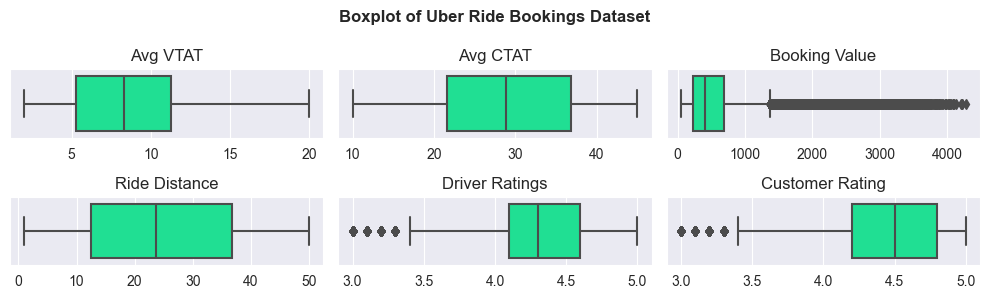

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(10,3))
axes=axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(data=uber_df,
                x=col,
                ax=axes[i],
                color='#00ff99')
    axes[i].set_title(num_cols[i])
    axes[i].set_xlabel('')
    plt.tight_layout()

plt.suptitle("Boxplot of Uber Ride Bookings Dataset", fontsize=12, fontweight='bold')
plt.tight_layout(rect=[0,0,1,1])
plt.show()

**'Booking Value'**,**'Driver Ratings'**, and **'Customer Rating'** contain outliers.

In [21]:
def outlier_iqr(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    
    outlier = data[(data[col] > (Q3 + 1.5*IQR)) | (data[col] < (Q1 - 1.5*IQR))]
    return outlier[[col]]

#### 'Booking Value' Outliers

In [22]:
outlier_iqr(uber_df, 'Booking Value')

,Booking Value
29,2847.0
50,1581.0
80,1390.0
91,2169.0
212,1543.0
...,...
149665,1593.0
149695,3161.0
149898,2842.0
149942,3028.0


**'Booking Value'** has **3435 datapoints** that are considered as outliers.

#### 'Driver Ratings' Outlier

In [23]:
outlier_iqr(uber_df, 'Driver Ratings')

,Driver Ratings
29,3.1
60,3.3
67,3.2
92,3.2
102,3.2
...,...
149881,3.2
149908,3.2
149927,3.1
149934,3.0


**'Driver Ratings'** has **5203 datapoints** that are considered as outliers.

#### 'Customer Rating' Outliers

In [24]:
outlier_iqr(uber_df, 'Customer Rating')

,Customer Rating
49,3.3
60,3.3
207,3.2
223,3.1
253,3.1
...,...
149877,3.2
149899,3.0
149909,3.3
149914,3.2


**'Customer Rating'** has **3257 datapoints** that are considered as outliers.

### 3.3. Re-formatting

In [25]:
uber_df = uber_df.rename(columns={'Reason for cancelling by Customer':'Customer Cancellation Reason'})

In [26]:
uber_df["Booking ID"] = uber_df["Booking ID"].str.strip('"')
uber_df["Customer ID"] = uber_df["Customer ID"].str.strip('"')

In [27]:
uber_df['Time'] = pd.to_datetime(uber_df['Date'] + ' ' + uber_df["Time"], format="%Y-%m-%d %H:%M:%S")
uber_df.drop(columns='Date', inplace=True)

In [28]:
uber_df = uber_df.sort_values(by='Time').reset_index(drop=True)
uber_df.head()

,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Customer Cancellation Reason,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-01-01 00:19:34,CNR4352144,Completed,CID8362794,Bike,Udyog Vihar,Ambience Mall,10.8,38.9,0,N/A,0,N/A,0,N/A,99.0,37.98,4.8,4.8,Cash
1,2024-01-01 01:35:18,CNR9147645,Completed,CID8300238,Go Mini,Basai Dhankot,Madipur,8.5,15.1,0,N/A,0,N/A,0,N/A,114.0,39.29,4.2,4.1,Uber Wallet
2,2024-01-01 01:37:50,CNR1009222,Cancelled by Driver,CID2030746,Go Sedan,Tughlakabad,Greater Kailash,7.4,NaN,0,N/A,1,More than permitted people in there,0,N/A,NaN,NaN,NaN,NaN,NaN
3,2024-01-01 01:48:03,CNR2740479,Cancelled by Driver,CID3231181,Auto,Palam Vihar,Kherki Daula Toll,5.6,NaN,0,N/A,1,Personal & Car related issues,0,N/A,NaN,NaN,NaN,NaN,NaN
4,2024-01-01 01:49:56,CNR7650148,Cancelled by Driver,CID3381661,Go Sedan,Narsinghpur,Pulbangash,6.2,NaN,0,N/A,1,More than permitted people in there,0,N/A,NaN,NaN,NaN,NaN,NaN


## 4. Exploratory Data Analysis

In [29]:
uber_df

,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Customer Cancellation Reason,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-01-01 00:19:34,CNR4352144,Completed,CID8362794,Bike,Udyog Vihar,Ambience Mall,10.8,38.9,0,N/A,0,N/A,0,N/A,99.0,37.98,4.8,4.8,Cash
1,2024-01-01 01:35:18,CNR9147645,Completed,CID8300238,Go Mini,Basai Dhankot,Madipur,8.5,15.1,0,N/A,0,N/A,0,N/A,114.0,39.29,4.2,4.1,Uber Wallet
2,2024-01-01 01:37:50,CNR1009222,Cancelled by Driver,CID2030746,Go Sedan,Tughlakabad,Greater Kailash,7.4,NaN,0,N/A,1,More than permitted people in there,0,N/A,NaN,NaN,NaN,NaN,NaN
3,2024-01-01 01:48:03,CNR2740479,Cancelled by Driver,CID3231181,Auto,Palam Vihar,Kherki Daula Toll,5.6,NaN,0,N/A,1,Personal & Car related issues,0,N/A,NaN,NaN,NaN,NaN,NaN
4,2024-01-01 01:49:56,CNR7650148,Cancelled by Driver,CID3381661,Go Sedan,Narsinghpur,Pulbangash,6.2,NaN,0,N/A,1,More than permitted people in there,0,N/A,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,2024-12-30 22:58:00,CNR9030698,Completed,CID6939658,Bike,DLF Phase 3,Okhla,6.9,35.8,0,N/A,0,N/A,0,N/A,440.0,12.85,4.4,4.8,UPI
149996,2024-12-30 23:03:14,CNR1507833,Completed,CID9905090,eBike,Saket,Noida Sector 62,7.9,33.6,0,N/A,0,N/A,0,N/A,279.0,39.36,3.8,4.3,UPI
149997,2024-12-30 23:17:05,CNR2265113,Completed,CID4170406,Go Mini,GTB Nagar,Anand Vihar ISBT,9.9,39.9,0,N/A,0,N/A,0,N/A,1855.0,38.91,4.3,4.6,UPI
149998,2024-12-30 23:21:12,CNR4066733,Completed,CID8938559,Uber XL,Ashram,Vasant Kunj,2.6,26.7,0,N/A,0,N/A,0,N/A,520.0,36.37,5.0,4.3,Uber Wallet


In [30]:
uber_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 20 columns):
 #   Column                        Non-Null Count   Dtype         
---  ------                        --------------   -----         
 0   Time                          150000 non-null  datetime64[ns]
 1   Booking ID                    150000 non-null  object        
 2   Booking Status                150000 non-null  object        
 3   Customer ID                   150000 non-null  object        
 4   Vehicle Type                  150000 non-null  object        
 5   Pickup Location               150000 non-null  object        
 6   Drop Location                 150000 non-null  object        
 7   Avg VTAT                      139500 non-null  float64       
 8   Avg CTAT                      102000 non-null  float64       
 9   Cancelled Rides by Customer   150000 non-null  int32         
 10  Customer Cancellation Reason  150000 non-null  object        
 11  Cancelled Rid

There are **6 numeric columns**:

> 'Avg VTAT', 'Avg CTAT', 'Booking Value', 'Ride Distance', 'Driver Ratings', 'Customer Rating'

**1 datetime columns**:

>'Time'

and **13 categorical columns**.

In [31]:
uber_df[['Time', 'Booking ID', 'Customer ID']].describe()

,Time,Booking ID,Customer ID
count,150000,150000,150000
unique,149532,148767,148788
top,2024-01-13 09:16:53,CNR2726142,CID4523979
freq,3,3,3
first,2024-01-01 00:19:34,NaN,NaN
last,2024-12-30 23:36:11,NaN,NaN


Customer with the ID **CID4523979** booked the most rides in 2024, with a total of 3 trips.

In [32]:
cust_counts = uber_df['Customer ID'].value_counts()
cust_counts[cust_counts.values == 3]

CID4523979    3
CID7828101    3
CID6715450    3
CID5481002    3
CID8727691    3
CID6468528    3
Name: Customer ID, dtype: int64

Other than customer with the ID of CID4523979, there are **5 more customers** who booked an Uber ride 3 times throughout 2024.

### 4.1. Univariate Analysis

#### 4.1.1. Categorical Variables

In [33]:
cat_cols = ['Booking Status', 'Vehicle Type', 'Pickup Location', 
            'Drop Location', 'Cancelled Rides by Customer', 'Customer Cancellation Reason',
            'Cancelled Rides by Driver', 'Driver Cancellation Reason', 'Incomplete Rides',
            'Incomplete Rides Reason', 'Payment Method']
len(cat_cols)

11

In [34]:
uber_df[cat_cols].describe(include='object')

,Booking Status,Vehicle Type,Pickup Location,Drop Location,Customer Cancellation Reason,Driver Cancellation Reason,Incomplete Rides Reason,Payment Method
count,150000,150000,150000,150000,150000,150000,150000,102000
unique,5,7,176,176,6,5,4,5
top,Completed,Auto,Khandsa,Ashram,N/A,N/A,N/A,UPI
freq,93000,37419,949,936,139500,123000,141000,45909


In [35]:
uber_df['Time'].describe()

count                  150000
unique                 149532
top       2024-01-13 09:16:53
freq                        3
first     2024-01-01 00:19:34
last      2024-12-30 23:36:11
Name: Time, dtype: object

In [36]:
for col in cat_cols:
    print(f'-- Value Count for "{col}" --')
    print(uber_df[col].value_counts())
    print('')

-- Value Count for "Booking Status" --
Completed                93000
Cancelled by Driver      27000
No Driver Found          10500
Cancelled by Customer    10500
Incomplete                9000
Name: Booking Status, dtype: int64

-- Value Count for "Vehicle Type" --
Auto             37419
Go Mini          29806
Go Sedan         27141
Bike             22517
Premier Sedan    18111
eBike            10557
Uber XL           4449
Name: Vehicle Type, dtype: int64

-- Value Count for "Pickup Location" --
Khandsa             949
Barakhamba Road     946
Saket               931
Badarpur            921
Pragati Maidan      920
                   ... 
Chirag Delhi        800
Noida Sector 18     799
Laxmi Nagar         797
Ashok Vihar         796
Ghitorni Village    790
Name: Pickup Location, Length: 176, dtype: int64

-- Value Count for "Drop Location" --
Ashram              936
Basai Dhankot       917
Lok Kalyan Marg     916
Narsinghpur         913
Kalkaji             912
                   ... 
MG

##### 4.1.1.1. Booking Status, Vehicle Type, Payment Method

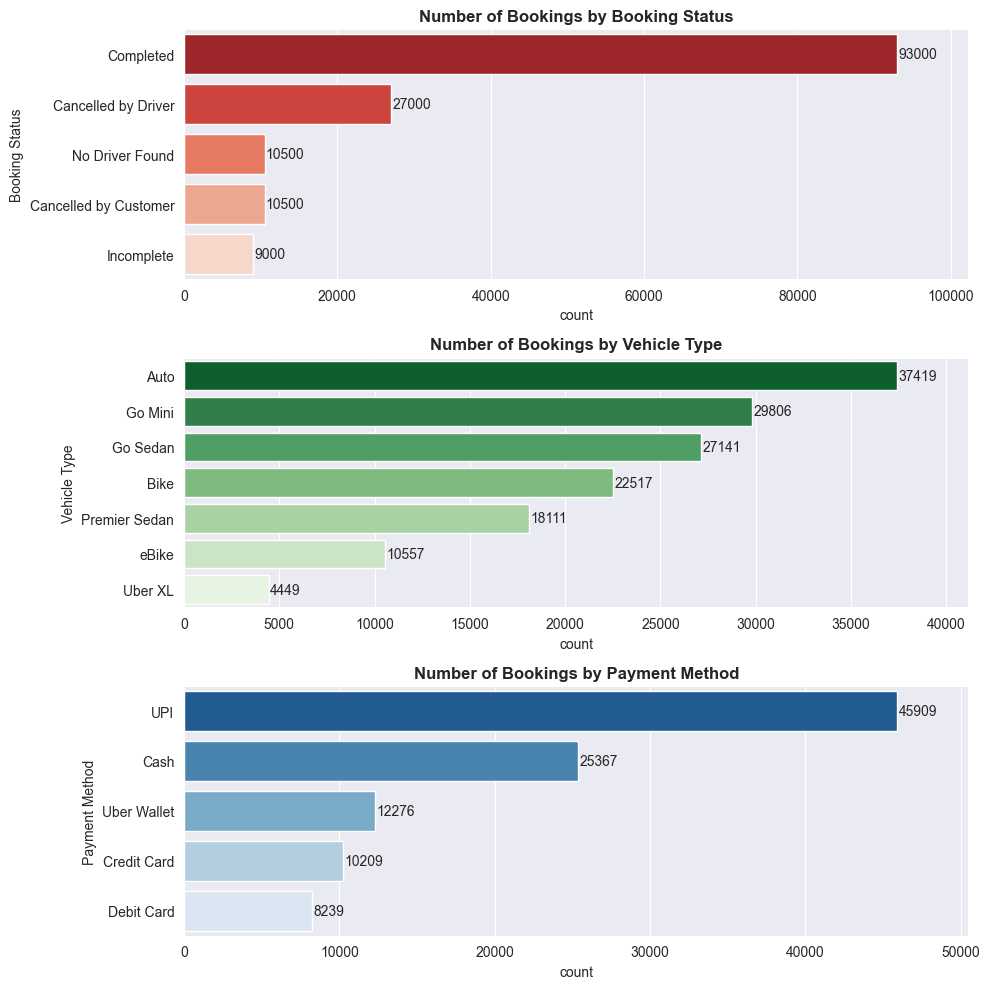

In [37]:
fig, axes = plt.subplots(3, 1, figsize=(10,10))
axes = axes.flatten()

for i, col in enumerate([['Booking Status', 'Reds'], ['Vehicle Type', 'Greens'], ['Payment Method', 'Blues']]):
    ax = sns.countplot(data=uber_df, 
                       y=col[0], 
                       ax=axes[i], 
                       order=uber_df[col[0]].value_counts().index,
                       palette=f'{col[1]}_r')
    for container in ax.containers:
        ax.bar_label(container, padding=1)
    ax.set_title(f'Number of Bookings by {col[0]}', fontweight='bold')
    ax.margins(x=0.1)
    

plt.tight_layout()

**`'Booking Status'`**
> 18% of all trips throughout 2024 were cancelled by drivers, and another 7% were automatically cancelled because no driver was found. In total, around **25% of all bookings in 2024 were cancelled from the driver side**. Based on this information, Uber can:
> - **Investigate further the causes of high frequency of cancellation from the driver's side**, as some reasons were quite unclear (customer-related issue, personal issue)
> - **Design an incentive program** to further encourage drivers to accept orders.

**`'Vehicle Type'`**
> Vehicle type 'Auto' was the most chosen by customers, with 37.419 orders (24,9%) throughout 2024, followed by 'Go Mini' with 29.806 orders (19,9%), 'Go Sedan' with 27.141 orders (18,1%), and so on. **Those 3 vehicle type accounted for around 62,9% of the total bookings in 2024, making them the core business of Uber in India**. For further improvement, Uber can:
> - **Focus on improving the service quality of those three services**
> - **Introduce a new promotional/loyalty reward programs** to maintain its market share.

**`'Payment Method'`**
> Out of 102.000 records of payment methods used by customers, **around 45% of them used Unified Payments Interface (UPI)** as the payment method, followed by **Cash at around 24,9% of total orders**, and so on. This indicates that customers are more comfortable at using UPI and Cash as the primary payment method. Therefore, Uber can:
> - **Focus on these two methods to boost transaction volume**, for example by offering promotions, discounts, or loyalty rewards by those payment methods.
> - **Conduct a survey to identify users' concerns** regarding the less used payment methods.

***

##### 4.1.1.2. Cancelled Rides Analysis

In [38]:
cust_canc_reason = uber_df[uber_df['Customer Cancellation Reason'] != 'N/A']['Customer Cancellation Reason']
drv_canc_reason = uber_df[uber_df['Driver Cancellation Reason'] != 'N/A']['Driver Cancellation Reason']
incomplete_reason = uber_df[uber_df['Incomplete Rides Reason'] != 'N/A']['Incomplete Rides Reason']

In [39]:
incomplete_reason.value_counts()

Customer Demand      3040
Vehicle Breakdown    3012
Other Issue          2948
Name: Incomplete Rides Reason, dtype: int64

In [40]:
incomplete_reason.value_counts()[1] / uber_df.shape[0]

0.02008

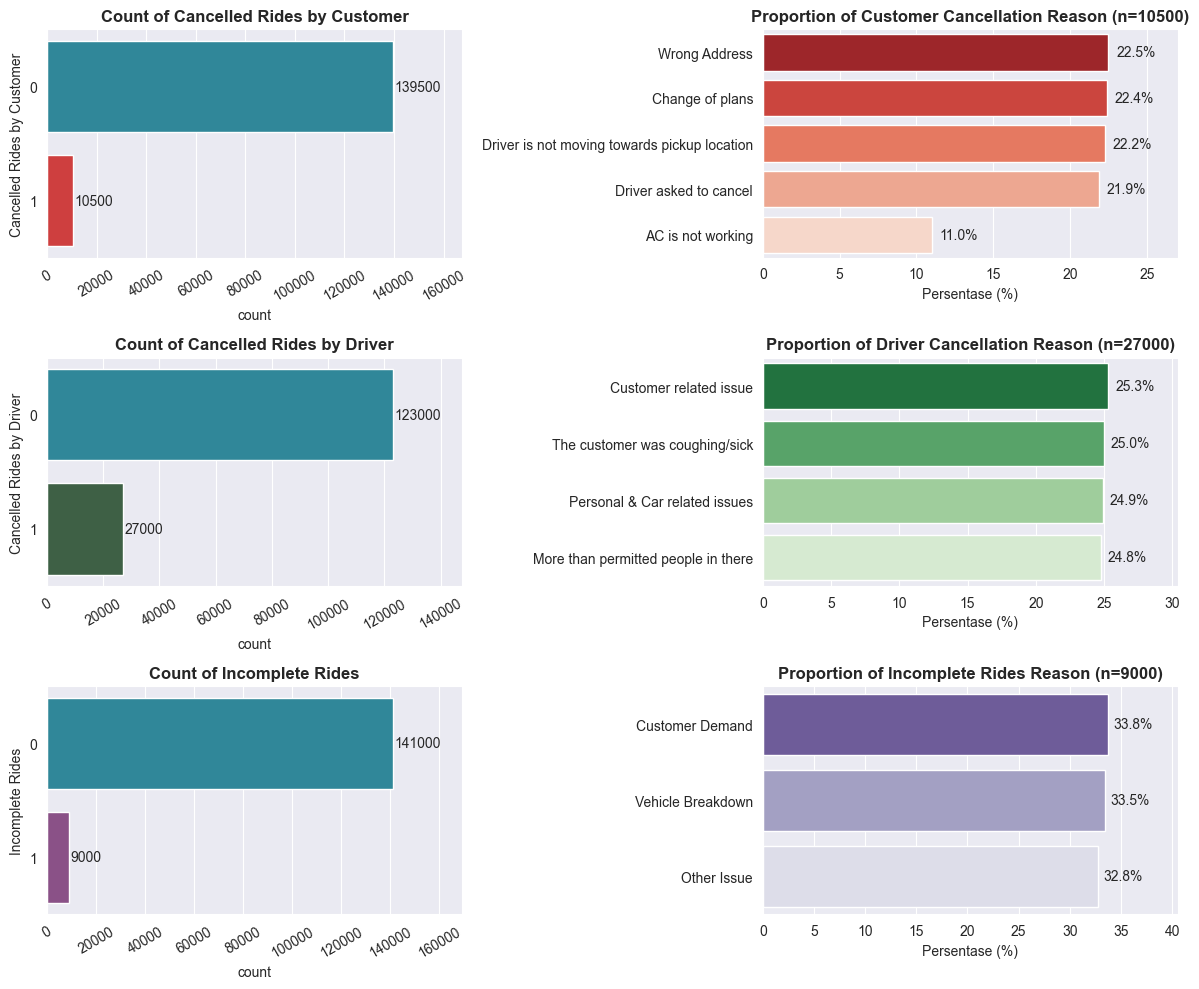

In [41]:
fig, axes = plt.subplots(3, 2, figsize=(12,10))
axes = axes.flatten()

for i, col in enumerate(['Cancelled Rides by Customer', cust_canc_reason, 
                         'Cancelled Rides by Driver', drv_canc_reason,
                         'Incomplete Rides', incomplete_reason]):
    ax = axes[i]
    
    if i % 2 == 0:
        data = uber_df[col]
        title = col
        clr_1 = ['#E62727', '#386641', '#934790']
        
        ax = sns.countplot(y=data,
                           order=data.value_counts().index,
                           ax=axes[i],
                           palette=['#1E93AB', clr_1[int(i/2)]])
        for container in ax.containers:
            ax.bar_label(container, padding=1)
            
        ax.set_title(f'Count of {title}', fontweight='bold')
        ax.margins(x=0.2)
        plt.setp(ax.get_xticklabels(), rotation=30)
        
    else:
        data = col
        count = data.value_counts()
        perc = data.value_counts(normalize=True) * 100
        title = col.name
        clr_2 = ['Reds_r', 'Greens_r', 'Purples_r']
        
        ax = sns.barplot(x=perc.values,
                         y=perc.index,
                         ax=axes[i],
                         palette=clr_2[int(i/2)])
        for idx, val in enumerate(perc.values):
            ax.text(val + 0.5, idx, f'{val:.1f}%', va='center') 
        ax.set_title(f'Proportion of {title} (n={count.sum()})', fontweight='bold')
        ax.set_xlabel('Persentase (%)')
        ax.margins(x=0.2)
    
plt.tight_layout()
plt.show()

**`'Cancelled Rides by Customer'`**
> Throughout 2024, **10.500 orders**, or about **7% of the total bookings, were cancelled by customers**. Customer cancellations were not only triggered by customer-related factors, but also by driver behavior and fleet quality. This suggests that:
> - **_Uber should focus on improving address validation and driver service control_**. This could include monitoring driver movements in real-time and implementing penalty mechanisms for drivers that are not moving towards the pickup location deliberately.

**`'Cancelled Rides by Driver'`**
> Driver-cancelled rides in 2024 reached approximately 18% out of 150.000 orders, meaning **1 of 5 orders were cancelled by drivers**, which is relatively high. These cancellations were caused by both customer-related and driver-related factors. **Uber can take the following actions to solve these problems.**
> - **Implement pre-screening features** to minimize the risk of cancellations due to health-related reasons.
> - **Specify cancellation reasons even further**, as there were unclear factors that caused the trips to be cancelled, which account for approximately half of all the cancelled trips.

**`'Incomplete Rides'`**
> **6.4% of the Uber ride bookings in 2024 were incomplete**. Out of 9000 incomplete trips, **33,5% were caused by vehicle breakdown**, which is around 3000 rides. This means **there was a 2% chance that a vehicle breakdown occurred in the middle of the trip**. Based on this information, Uber can take several actions, as follows:
> - **Implement a vehicle service incentives** or discounts periodically for drivers at partner workshops
> - **Specify reasons classified as 'Other issue'** into a more detailed categories (e.g., extreme traffic jam, severe weather, etc.)

##### 4.1.1.3. Time-Based Analysis

In [42]:
uber_df_2 = uber_df.copy()

In [43]:
uber_df_2['Day'] = uber_df_2["Time"].dt.day_name()
uber_df_2.head()

,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Customer Cancellation Reason,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method,Day
0,2024-01-01 00:19:34,CNR4352144,Completed,CID8362794,Bike,Udyog Vihar,Ambience Mall,10.8,38.9,0,N/A,0,N/A,0,N/A,99.0,37.98,4.8,4.8,Cash,Monday
1,2024-01-01 01:35:18,CNR9147645,Completed,CID8300238,Go Mini,Basai Dhankot,Madipur,8.5,15.1,0,N/A,0,N/A,0,N/A,114.0,39.29,4.2,4.1,Uber Wallet,Monday
2,2024-01-01 01:37:50,CNR1009222,Cancelled by Driver,CID2030746,Go Sedan,Tughlakabad,Greater Kailash,7.4,NaN,0,N/A,1,More than permitted people in there,0,N/A,NaN,NaN,NaN,NaN,NaN,Monday
3,2024-01-01 01:48:03,CNR2740479,Cancelled by Driver,CID3231181,Auto,Palam Vihar,Kherki Daula Toll,5.6,NaN,0,N/A,1,Personal & Car related issues,0,N/A,NaN,NaN,NaN,NaN,NaN,Monday
4,2024-01-01 01:49:56,CNR7650148,Cancelled by Driver,CID3381661,Go Sedan,Narsinghpur,Pulbangash,6.2,NaN,0,N/A,1,More than permitted people in there,0,N/A,NaN,NaN,NaN,NaN,NaN,Monday


In [44]:
uber_df_2['Hour'] = uber_df_2['Time'].dt.hour

In [45]:
uber_df_2['Hour'].value_counts()

18    12397
19    11047
17    11044
16     9633
20     9630
10     9577
11     8390
9      8234
15     8202
21     8103
14     7031
12     7006
8      6861
13     5470
7      5450
22     5441
6      4160
5      2786
23     2762
3      1383
0      1373
1      1360
2      1339
4      1321
Name: Hour, dtype: int64

The value 0 in the 'Hour' column will be converted to 24 to improve interpretability during visualization later.

In [46]:
uber_df_2['Hour'] = uber_df_2['Hour'].replace(0, 24)

**a. Number of Rides by Hour**

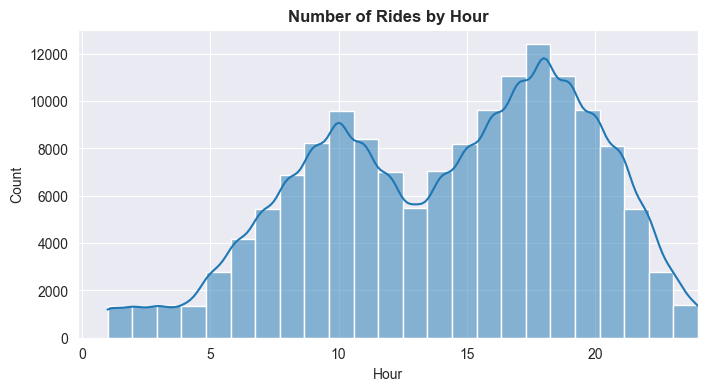

In [47]:
plt.figure(figsize=(8,4))
sns.histplot(data=uber_df_2, 
             x='Hour', 
             kde=True,
             bins=24)

plt.xlim(right=24)
plt.title('Number of Rides by Hour', fontweight='bold')
plt.show()

Peak hours of Uber ride bookings in India in 2024 were around **10 AM** and **06 PM**, which were typically regarded as the **commuting hours for work departure and return**.

**b. Number of Rides by Day**

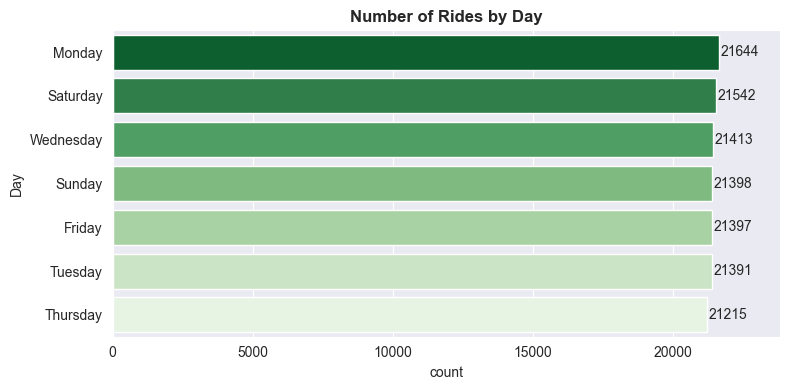

In [48]:
plt.figure(figsize=(8,4))
ax = sns.countplot(data=uber_df_2, 
                   y='Day',
                   order=uber_df_2['Day'].value_counts().index,
                   palette='Greens_r')
for container in ax.containers:
    ax.bar_label(container, padding=1)

plt.title('Number of Rides by Day', fontweight='bold')
plt.margins(x=0.1)
plt.tight_layout()
plt.show()

No significant difference was observed in the number of bookings across different days, suggesting that **booking volume remained relatively stable on a day-to-day basis**.

**c. Number of Rides by Hour Each Day**

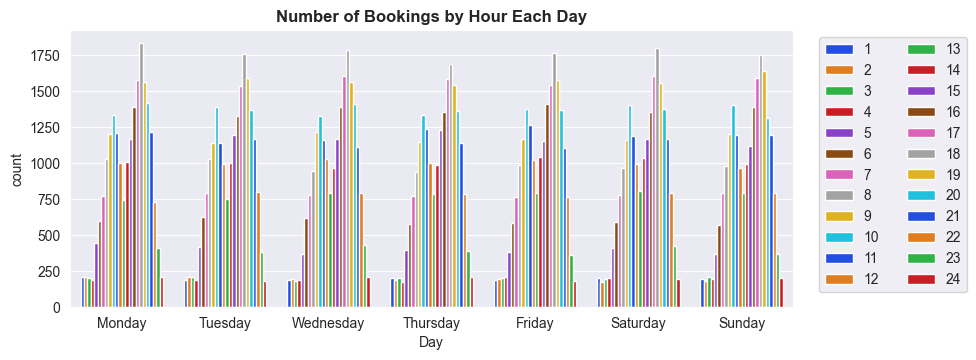

In [49]:
plt.figure(figsize=(10,3.5))
sns.countplot(data=uber_df_2, x='Day', hue='Hour', palette='bright')

plt.legend(loc='upper right', bbox_to_anchor=(1.25, 1), ncol=2)
plt.tight_layout()
plt.title('Number of Bookings by Hour Each Day', fontsize=12, fontweight='bold')
plt.show()

**There isn't any significant difference** in the pattern of bookings by hour across different days.

**d. Number of Daily Completed Rides in 2024**

In [50]:
completed_rides = uber_df_2[uber_df_2['Booking Status'] == 'Completed']
completed_rides

,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Customer Cancellation Reason,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method,Day,Hour
0,2024-01-01 00:19:34,CNR4352144,Completed,CID8362794,Bike,Udyog Vihar,Ambience Mall,10.8,38.9,0,N/A,0,N/A,0,N/A,99.0,37.98,4.8,4.8,Cash,Monday,24
1,2024-01-01 01:35:18,CNR9147645,Completed,CID8300238,Go Mini,Basai Dhankot,Madipur,8.5,15.1,0,N/A,0,N/A,0,N/A,114.0,39.29,4.2,4.1,Uber Wallet,Monday,1
5,2024-01-01 01:53:01,CNR8140858,Completed,CID9268400,Go Mini,Jhilmil,Welcome,8.1,42.6,0,N/A,0,N/A,0,N/A,735.0,39.39,4.3,4.7,UPI,Monday,1
13,2024-01-01 03:59:29,CNR6073090,Completed,CID7393428,Go Mini,Sarojini Nagar,Madipur,2.9,33.8,0,N/A,0,N/A,0,N/A,918.0,44.21,3.6,4.9,Cash,Monday,3
14,2024-01-01 04:00:07,CNR4082656,Completed,CID9685431,eBike,Panchsheel Park,Pragati Maidan,8.6,24.3,0,N/A,0,N/A,0,N/A,423.0,40.82,4.4,3.9,Cash,Monday,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149993,2024-12-30 22:55:36,CNR6401043,Completed,CID5129306,Premier Sedan,Munirka,Keshav Puram,6.8,21.0,0,N/A,0,N/A,0,N/A,450.0,10.87,4.9,4.8,UPI,Monday,22
149995,2024-12-30 22:58:00,CNR9030698,Completed,CID6939658,Bike,DLF Phase 3,Okhla,6.9,35.8,0,N/A,0,N/A,0,N/A,440.0,12.85,4.4,4.8,UPI,Monday,22
149996,2024-12-30 23:03:14,CNR1507833,Completed,CID9905090,eBike,Saket,Noida Sector 62,7.9,33.6,0,N/A,0,N/A,0,N/A,279.0,39.36,3.8,4.3,UPI,Monday,23
149997,2024-12-30 23:17:05,CNR2265113,Completed,CID4170406,Go Mini,GTB Nagar,Anand Vihar ISBT,9.9,39.9,0,N/A,0,N/A,0,N/A,1855.0,38.91,4.3,4.6,UPI,Monday,23


In [51]:
completed_rides['Date'] = completed_rides['Time'].dt.date
completed_rides.head()

,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Customer Cancellation Reason,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method,Day,Hour,Date
0,2024-01-01 00:19:34,CNR4352144,Completed,CID8362794,Bike,Udyog Vihar,Ambience Mall,10.8,38.9,0,N/A,0,N/A,0,N/A,99.0,37.98,4.8,4.8,Cash,Monday,24,2024-01-01
1,2024-01-01 01:35:18,CNR9147645,Completed,CID8300238,Go Mini,Basai Dhankot,Madipur,8.5,15.1,0,N/A,0,N/A,0,N/A,114.0,39.29,4.2,4.1,Uber Wallet,Monday,1,2024-01-01
5,2024-01-01 01:53:01,CNR8140858,Completed,CID9268400,Go Mini,Jhilmil,Welcome,8.1,42.6,0,N/A,0,N/A,0,N/A,735.0,39.39,4.3,4.7,UPI,Monday,1,2024-01-01
13,2024-01-01 03:59:29,CNR6073090,Completed,CID7393428,Go Mini,Sarojini Nagar,Madipur,2.9,33.8,0,N/A,0,N/A,0,N/A,918.0,44.21,3.6,4.9,Cash,Monday,3,2024-01-01
14,2024-01-01 04:00:07,CNR4082656,Completed,CID9685431,eBike,Panchsheel Park,Pragati Maidan,8.6,24.3,0,N/A,0,N/A,0,N/A,423.0,40.82,4.4,3.9,Cash,Monday,4,2024-01-01


In [52]:
daily_rides = completed_rides.groupby('Date').size()

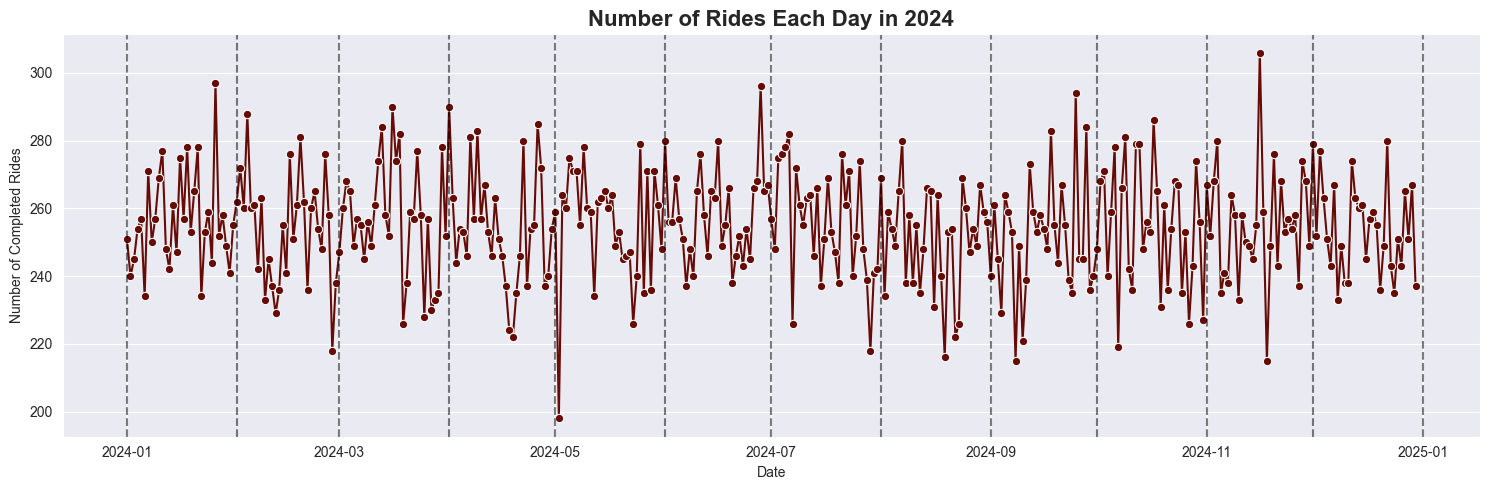

In [53]:
plt.figure(figsize=(15,5))
sns.lineplot(data=daily_rides, color='#660B05', marker='o')

for month in range(1,13):
    month_ts = pd.Timestamp(f'2024-{month}-01')
    plt.axvline(month_ts, color='k', linestyle='--', alpha=0.5)
plt.axvline(pd.Timestamp(f'2025-01-01'), color='k', linestyle='--', alpha=0.5)

plt.title('Number of Rides Each Day in 2024', fontsize=16, fontweight='bold')
plt.ylabel('Number of Completed Rides')
plt.tight_layout()
plt.show()

The number of daily rides seems to fluctuate, **with spikes and drops at a certain point in time**. Decomposition can be performed to identify any seasonality or trend in the data.

**e. Daily Rides Decomposition**

In [55]:
from statsmodels.tsa.seasonal import STL

In [56]:
daily_rides

Date
2024-01-01    251
2024-01-02    240
2024-01-03    245
2024-01-04    254
2024-01-05    257
             ... 
2024-12-26    243
2024-12-27    265
2024-12-28    251
2024-12-29    267
2024-12-30    237
Length: 365, dtype: int64

In [57]:
stl = STL(daily_rides, period=30)
result = stl.fit()

In [58]:
seasonal, trend, resid = result.seasonal, result.trend, result.resid

In [59]:
stl_element = [daily_rides, trend, seasonal]

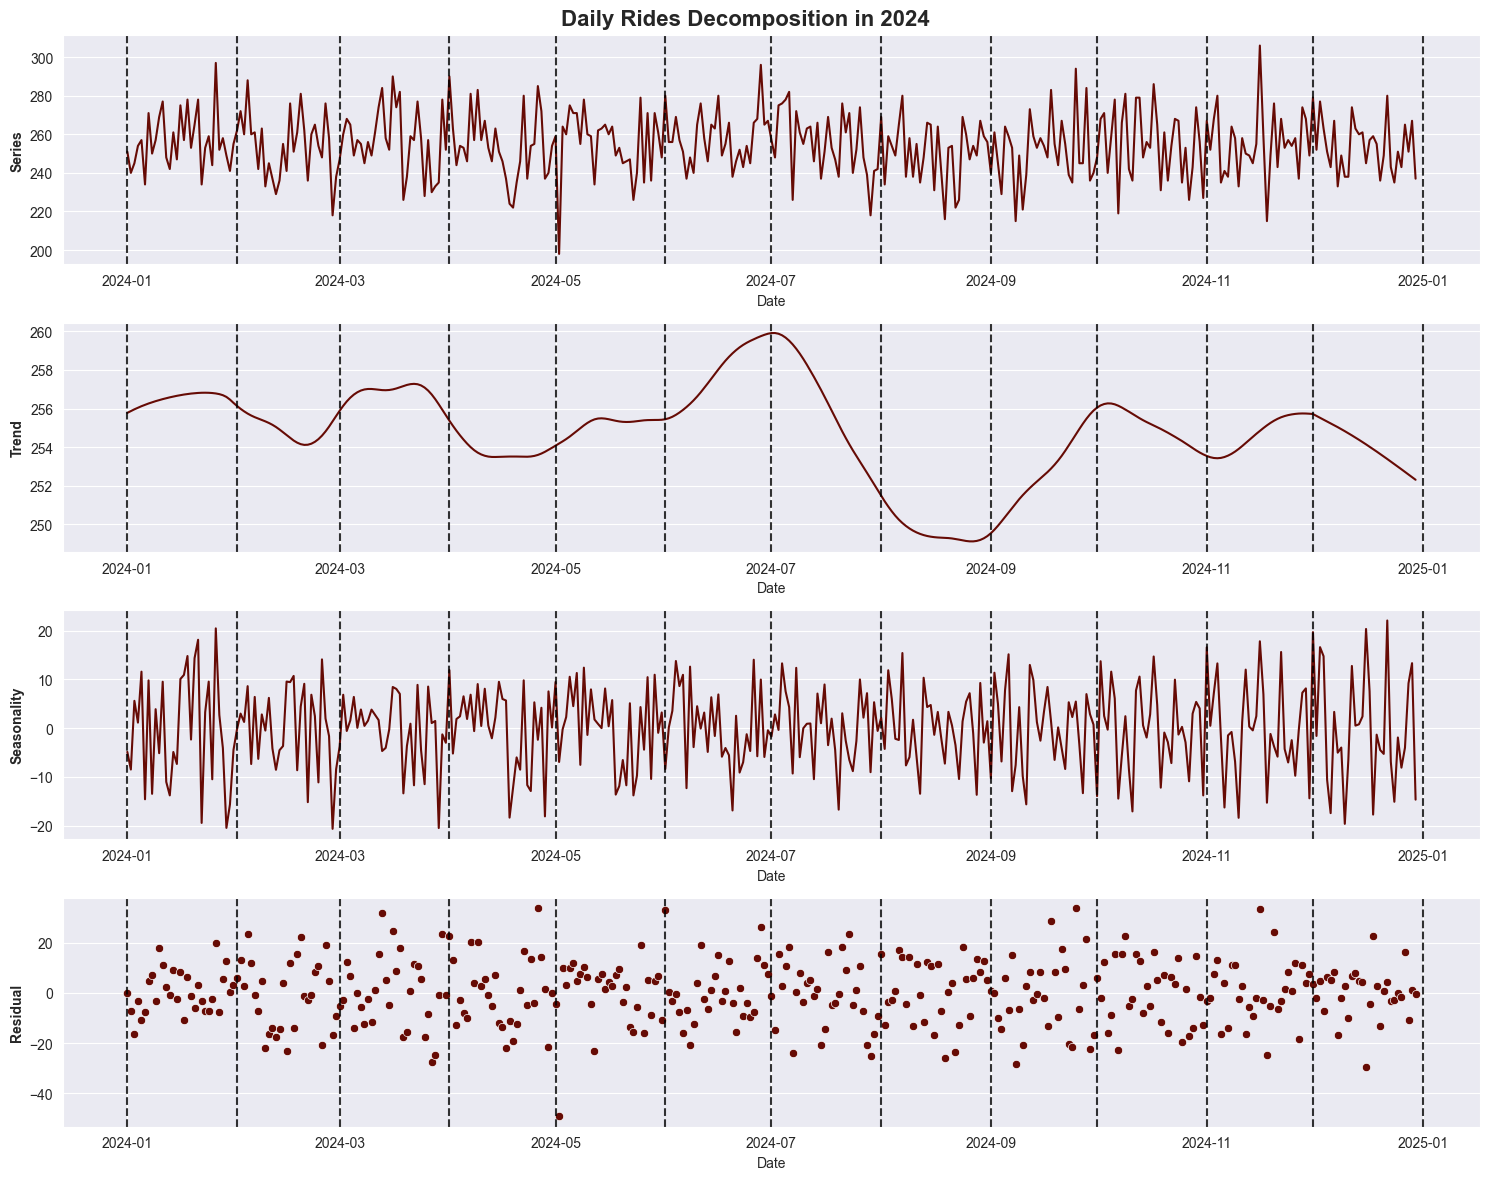

In [86]:
plt.figure(figsize=(15,12))
ylabel=['Series', 'Trend', 'Seasonality', 'Residual']
for index, element in enumerate(stl_element):
    plt.subplot(4,1,index+1)
    sns.lineplot(element, color='#660B05')
    plt.ylabel(ylabel[index], fontweight='bold')
    
    for month in range(1,13):
        month_stamp = pd.Timestamp(f'2024-{month}-01')
        plt.axvline(month_stamp, color='k', linestyle='--', alpha=0.8)
    plt.axvline(pd.Timestamp(f'2025-01-01'), color='k', linestyle='--', alpha=0.8)
    
plt.subplot(4,1,4)
sns.scatterplot(resid, color='#660B05')
plt.ylabel(ylabel[3], fontweight='bold')
for month in range(1,13):
    month_stamp = pd.Timestamp(f'2024-{month}-01')
    plt.axvline(month_stamp, color='k', linestyle='--', alpha=0.8)
plt.axvline(pd.Timestamp(f'2025-01-01'), color='k', linestyle='--', alpha=0.8)

plt.suptitle("Daily Rides Decomposition in 2024", fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 1])
plt.show()

**There isn't any clear seasonality or trend** in the daily rides data, and the residual also appeared to be randomly spread. Therefore, modeling with a time-series statistical model might be **less appropriate**. 

##### 4.1.1.4 Location Analysis

In [61]:
print(f"Number of Unique Pickup Locations: {uber_df['Pickup Location'].nunique()}")
print(f"Number of Unique Drop Locations: {uber_df['Drop Location'].nunique()}")

Number of Unique Pickup Locations: 176
Number of Unique Drop Locations: 176


In [62]:
top5_drops = uber_df['Drop Location'].value_counts().head(5)
top5_drops

Ashram             936
Basai Dhankot      917
Lok Kalyan Marg    916
Narsinghpur        913
Kalkaji            912
Name: Drop Location, dtype: int64

In [63]:
top5_pickups = uber_df['Pickup Location'].value_counts().head(5)
top5_pickups

Khandsa            949
Barakhamba Road    946
Saket              931
Badarpur           921
Pragati Maidan     920
Name: Pickup Location, dtype: int64

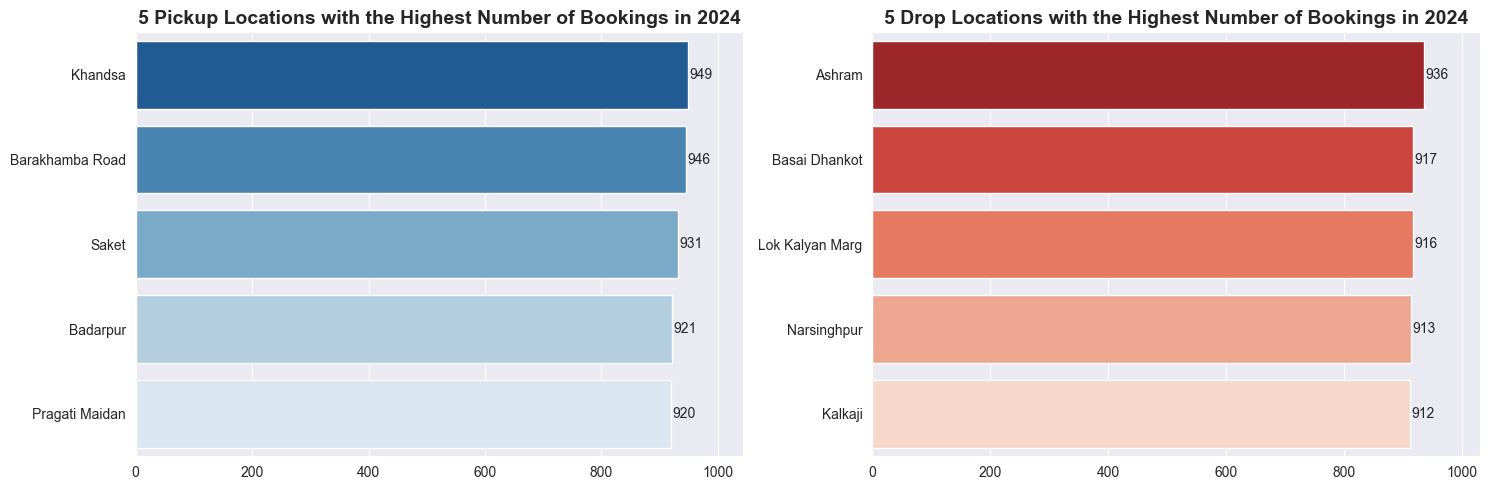

In [88]:
fig, axes = plt.subplots(1, 2, figsize = (15,5))
for i, data in enumerate([[top5_pickups, 'Blues_r', 'Pickup Locations'],
                          [top5_drops, 'Reds_r', 'Drop Locations']]):
    ax = sns.barplot(x=data[0].values,
                     y=data[0].index,
                     ax=axes[i],
                     palette=data[1])
    ax.set_title(f'5 {data[2]} with the Highest Number of Bookings in 2024', fontsize=14, fontweight='bold')
    for container in ax.containers:
        ax.bar_label(container, padding=1)
    ax.margins(x=0.1)

plt.tight_layout()
plt.show()

The visualization above showed the top locations with most bookings, each recording more than 900 bookings. Uber can take the following actions to improve business performance:
- **Increase driver supply in these locations**, for example by providing bonuses for drivers who remained on standby in those areas.
- **Adjust prices in these areas to ensure affordability for customers**, either through direct fare adjustments or by offering discounts to customers in those area.

***

#### 4.1.2. Numerical Variables

In [65]:
num_cols = ['Avg VTAT', 'Avg CTAT',
            'Booking Value', 'Ride Distance',
            'Driver Ratings', 'Customer Rating']

In [66]:
uber_df[num_cols].describe()

,Avg VTAT,Avg CTAT,Booking Value,Ride Distance,Driver Ratings,Customer Rating
count,139500.000000,102000.000000,102000.000000,102000.000000,93000.000000,93000.000000
mean,8.456352,29.149636,508.295912,24.637012,4.230992,4.404584
std,3.773564,8.902577,395.805774,14.002138,0.436871,0.437819
min,2.000000,10.000000,50.000000,1.000000,3.000000,3.000000
25%,5.300000,21.600000,234.000000,12.460000,4.100000,4.200000
50%,8.300000,28.800000,414.000000,23.720000,4.300000,4.500000
75%,11.300000,36.800000,689.000000,36.820000,4.600000,4.800000
max,20.000000,45.000000,4277.000000,50.000000,5.000000,5.000000


##### 4.1.2.1. Variable Distribution

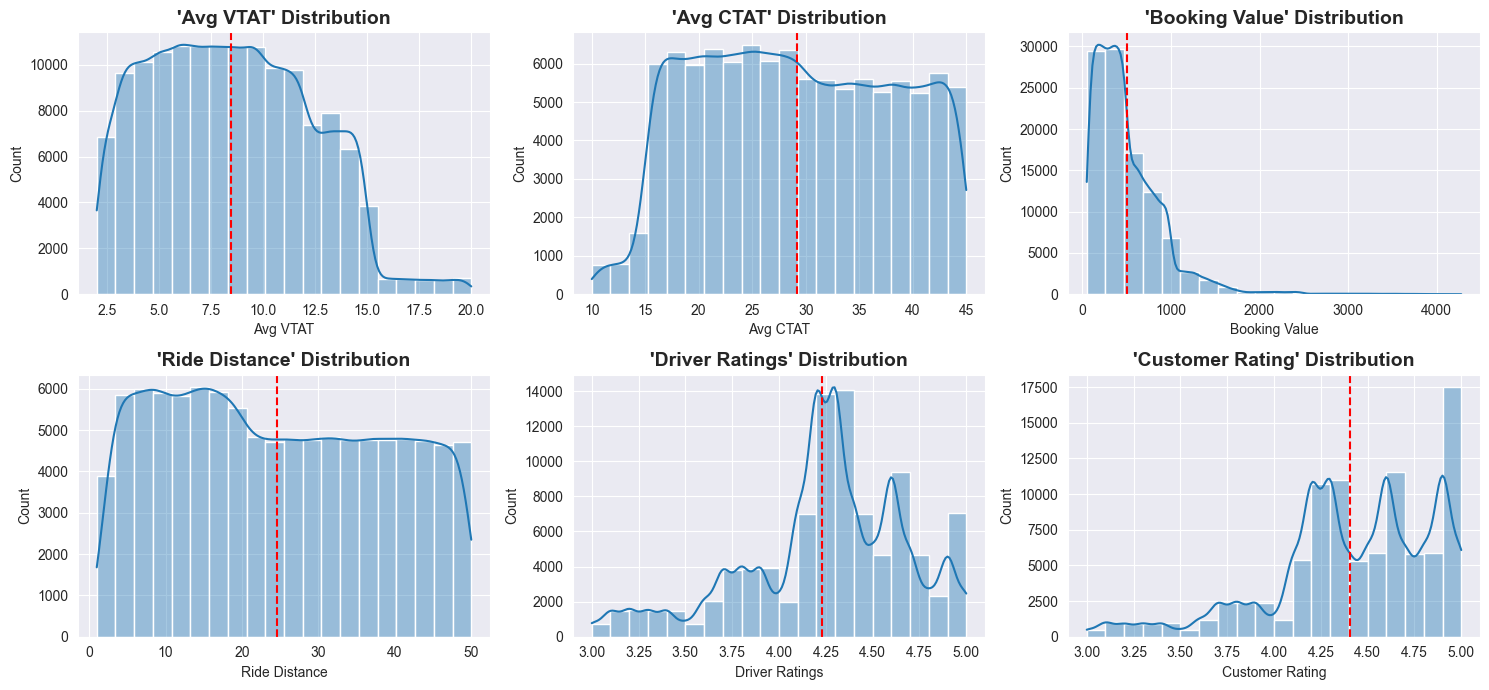

In [89]:
fig, axes = plt.subplots(2, 3, figsize=(15,7))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(uber_df, 
                 x=col,
                 bins=20,
                 ax=axes[i],
                 kde=True,
                 alpha=0.4)
    
    axes[i].axvline(
        x=uber_df[col].mean(),
        color='r',
        linestyle='--',
        alpha=1
    )
    
    axes[i].set_title(f"'{col}' Distribution", fontsize=14, fontweight='bold')
    
plt.tight_layout()
plt.show()

**`Avg VTAT`**
> This variable has a right-skewed distribution, with most of them in the range of 5-15. This means **most of the vehicles needed 5-15 minutes to arrive**. Still acceptable, but Uber can improve this further by:
> - **Increase driver supply in high-demand areas**.
> - **Identify paths (if possible) as shortcuts** for drivers, so that drivers can arrive earlier at the customer's location.

**`Avg CTAT`**
> The distribution tends to be flat after a value of 15, which means that **most customers spent around 15-45 minutes waiting on average, which may reduce satisfaction at rush hours**. Uber can improve this by: 
> - Provide a real-time traffic-based ETA for more accurate estimation
> - Give recommendation to customers for alternative transport modes

**`Booking Value`**
> The distribution is highly right-skewed, with the majority of the data falling below the value of 1000. This indicated that **most of the trips had costs ranging within 200-500**. Uber can implement the following to increase profitability:
> - **Connect short trips with other services** (e.g., ride + food delivery promotion)

**`Ride Distance`**
> Approximately 35.5% of all trips had a travel distance of around 5-20 km, but **more than 50% of the total trips in 2024 covered a distance of over 20 km**. A very small fraction (less than 0.001%) of the total trips recorded a travel distance of 50 km.

**`Driver Ratings`**
> In 2024, the distribution of 'Driver Ratings' were negatively skewed, exhibiting an average of driver ratings of approximately 4.2. **Only 30.2% of all trips gained driver ratings of 4.5 and above**. This is relatively low as many platforms expect driver ratings to be 4.6+ as the norm. This shows that customers might not be fully satisfied with driver performance (e.g., punctuality, behavior, vehicle condition, etc.), and **may discourage repeat usage from customers**. Uber can take these actions for improvements:
> - **Provide targeted improvement programs for drivers** (e.g., customer service skills, vehicle cleanliness, etc.)
> - **Set a minimum acceptable rating for drivers**. Drivers consistenly below this threshold may require re-training or even suspension.
> - **Collect feedbacks from customers** when they give ratings less than 4.5.

**`Customer Rating`**
> 80.097 trips, or approximately 86.1% of the total trips in 2024, had a customer rating above 4. **Half of the total trips received an even higher customer rating, exceeding 4.5**. This shows that **most of the customers behaved well**. However, in 13.9% of the trips in 2024, customers received a rating below 4. This may indicate issues like disrespectful behavior, and can be improved by doing the following:
> - **Offer small perks for customers with high ratings** (e.g., loyalty points, promo codes, etc.)
> - **Consistently track low-rated customers**. If patterns emerge, consider warnings (for both drivers and the corresponding customer), or even temporary suspensions.

***

### 4.2. Bivariate Analysis

In [68]:
print(f'Numerical Variables:\n{num_cols}\n')
print(f'Categorical Variables:\n{cat_cols}')

Numerical Variables:
['Avg VTAT', 'Avg CTAT', 'Booking Value', 'Ride Distance', 'Driver Ratings', 'Customer Rating']

Categorical Variables:
['Booking Status', 'Vehicle Type', 'Pickup Location', 'Drop Location', 'Cancelled Rides by Customer', 'Customer Cancellation Reason', 'Cancelled Rides by Driver', 'Driver Cancellation Reason', 'Incomplete Rides', 'Incomplete Rides Reason', 'Payment Method']


#### 4.2.1. Booking Value vs Vehicle Type

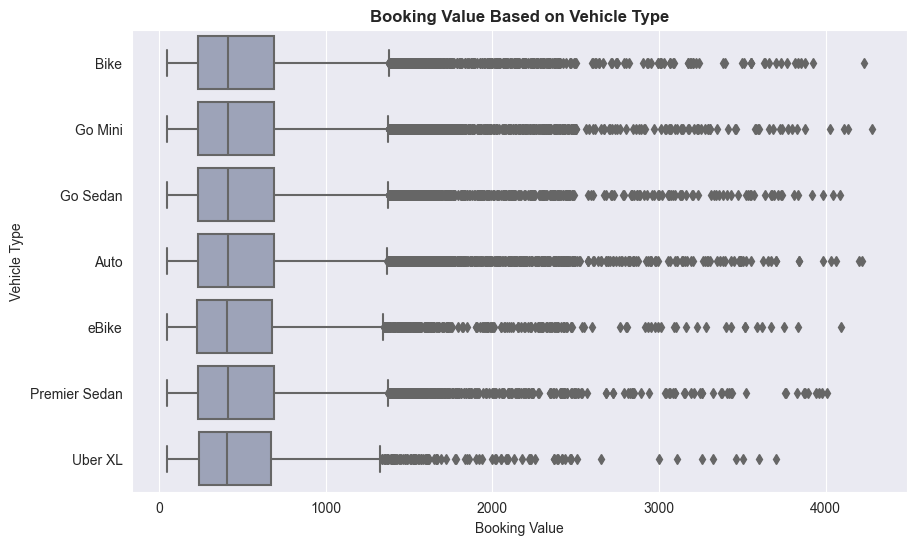

In [69]:
plt.figure(figsize=(10,6))
sns.boxplot(
    data=uber_df,
    x='Booking Value',
    y='Vehicle Type',
    color='#98A1BC'
)
plt.title('Booking Value Based on Vehicle Type', fontweight='bold')
plt.show()

In [70]:
vt_bv_grouped = uber_df[['Vehicle Type', 'Booking Value']].groupby('Vehicle Type').median()
vt_bv_grouped = vt_bv_grouped.rename(columns={'Booking Value':'Booking Value (Median)'}).T
vt_bv_grouped

Vehicle Type,Auto,Bike,Go Mini,Go Sedan,Premier Sedan,Uber XL,eBike
Booking Value (Median),414.0,416.0,412.0,416.0,416.0,406.0,410.0


**Vehicle type doesn't appear to affect booking value significantly**, as the median are at approximately the same value for each vehicle type, **ranging from 406 - 416**.

#### 4.2.2. Avg CTAT vs Vehicle Type

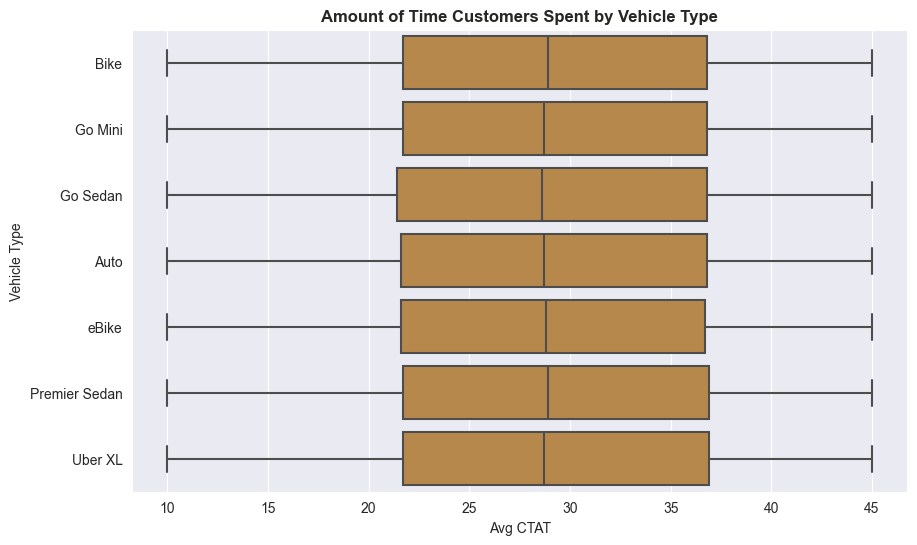

In [71]:
plt.figure(figsize=(10,6))
sns.boxplot(
    data=uber_df,
    x='Avg CTAT',
    y='Vehicle Type',
    color='#C78A3B'
)
plt.title('Amount of Time Customers Spent by Vehicle Type', fontweight='bold')
plt.show()

In [72]:
vt_ctat_grouped = uber_df[['Vehicle Type', 'Avg CTAT']].groupby('Vehicle Type').median()
vt_ctat_grouped = vt_ctat_grouped.rename(columns={'Avg CTAT':'Avg CTAT (Median)'}).T
vt_ctat_grouped

Vehicle Type,Auto,Bike,Go Mini,Go Sedan,Premier Sedan,Uber XL,eBike
Avg CTAT (Median),28.7,28.9,28.7,28.6,28.9,28.7,28.8


Customers spent a **relatively similar amount of time** across 7 different vehicle type, with a **median value of around 28.6 - 28.9**.

#### 4.2.3. Booking Value vs Payment Method

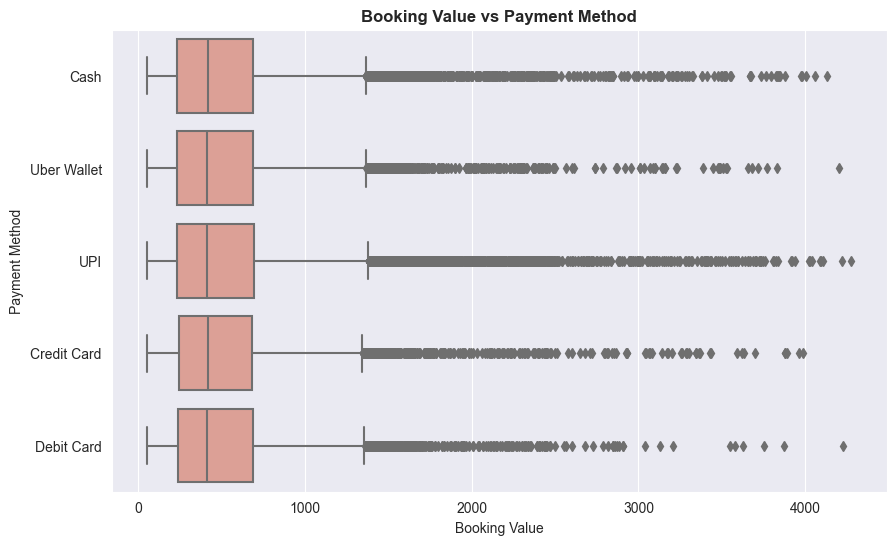

In [73]:
plt.figure(figsize=(10,6))
sns.boxplot(
    data=uber_df,
    x='Booking Value',
    y='Payment Method',
    color='#E8988A'
)
plt.title('Booking Value vs Payment Method', fontweight='bold')
plt.show()

In [74]:
bv_pm_grouped = uber_df[['Payment Method', 'Booking Value']].groupby('Payment Method').median()
bv_pm_grouped = bv_pm_grouped.rename(columns={'Booking Value':'Booking Value (Median)'}).T
bv_pm_grouped

Payment Method,Cash,Credit Card,Debit Card,UPI,Uber Wallet
Booking Value (Median),417.0,416.0,413.0,413.0,413.0


Customers spent a **similar amount of money** for their ride across 5 different payment methods, with a **median value ranging around 413 - 417**.

---

### 4.3. Multivariate Analysis

#### 4.3.1. Numeric Columns Pairwise Comparison

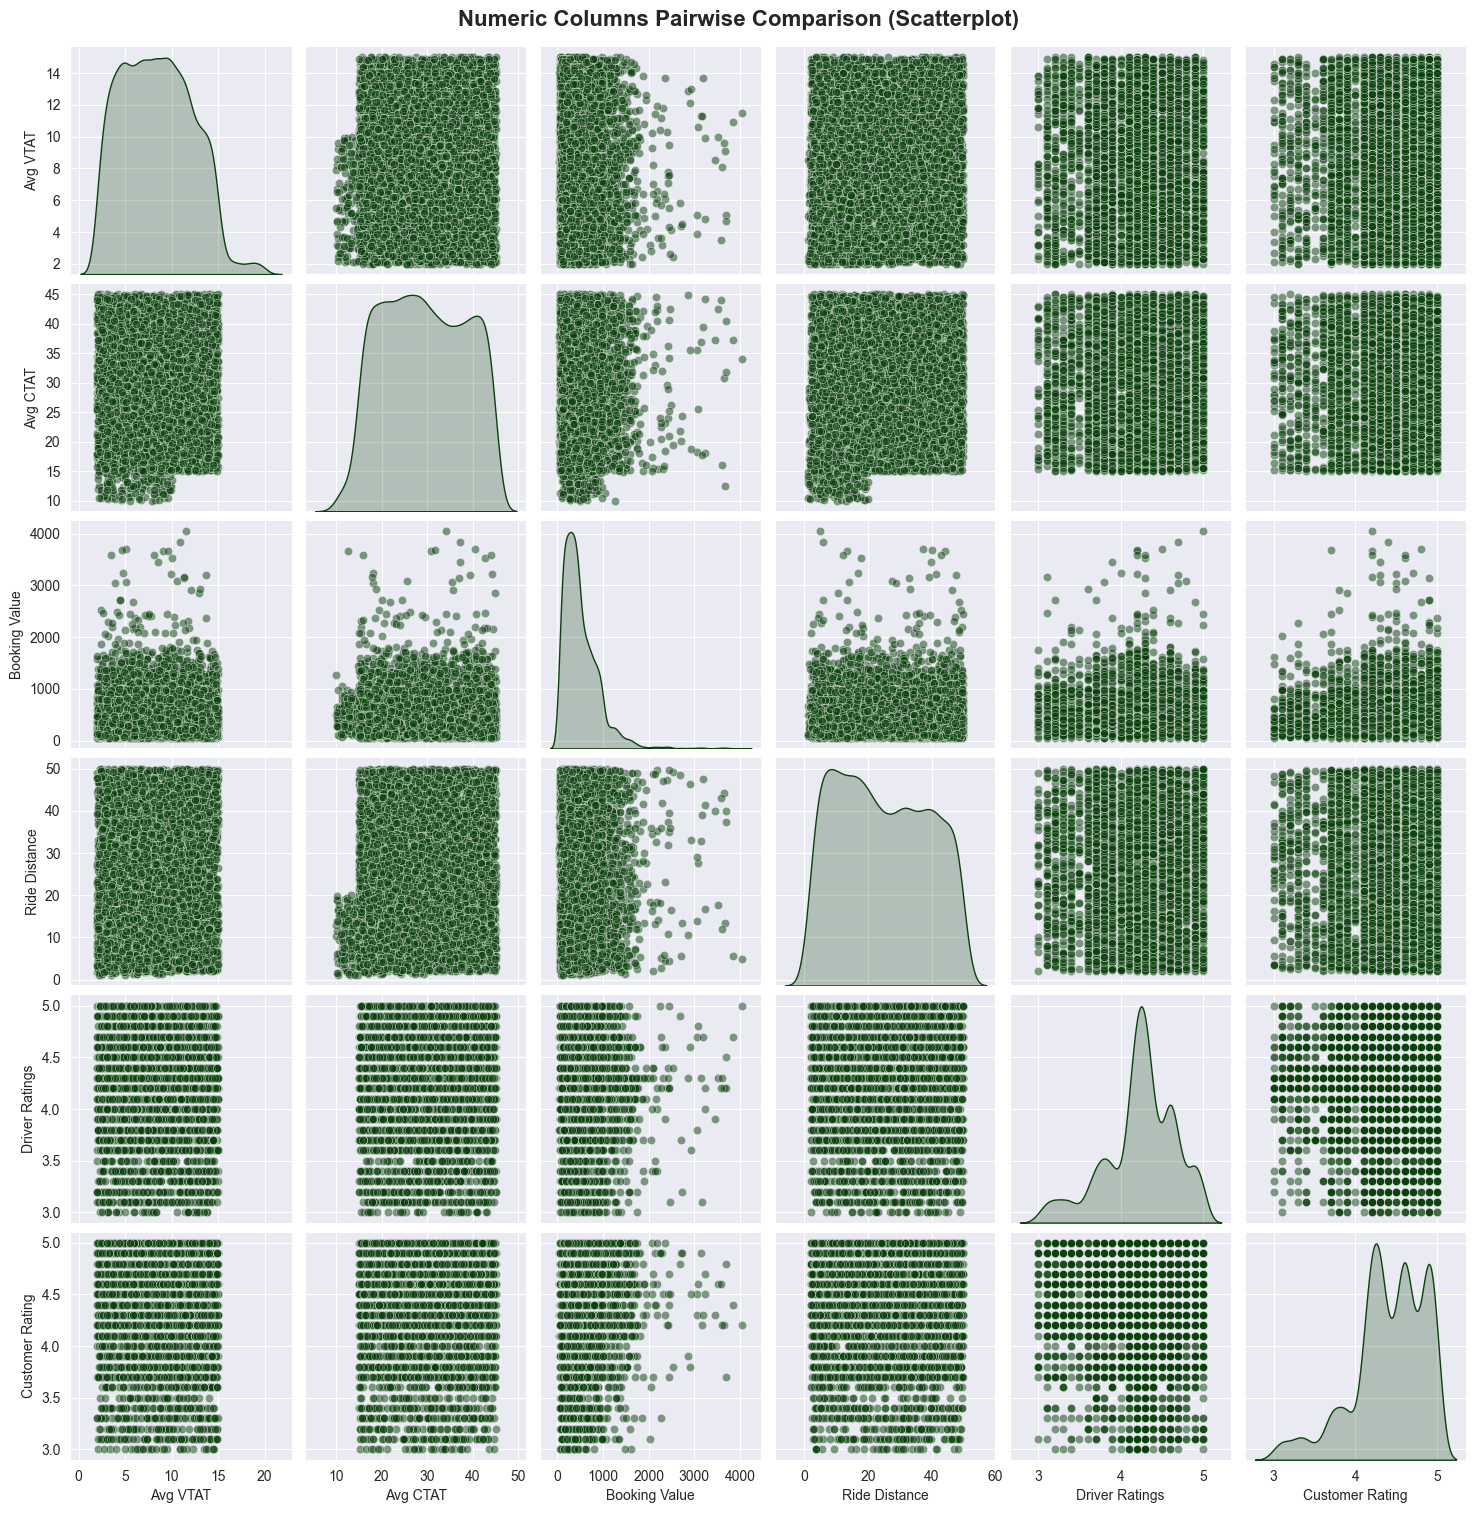

In [99]:
sns.pairplot(
    data=uber_df[num_cols].sample(10000, random_state=0),
    diag_kind='kde',
    plot_kws={'color':'#0A400C', 'alpha':0.5},
    diag_kws={'color':'#0A400C'}
)
plt.suptitle('Numeric Columns Pairwise Comparison (Scatterplot)', 
             fontsize=16, fontweight='bold',
             y=1.01, ha='center', va='top')
plt.show()

Based on the provided pairplot above, **no two variables appeared to have a strong relationship**. This is quantitatively confirmed by the correlation matrix below.

#### 4.3.2. Correlation Matrix

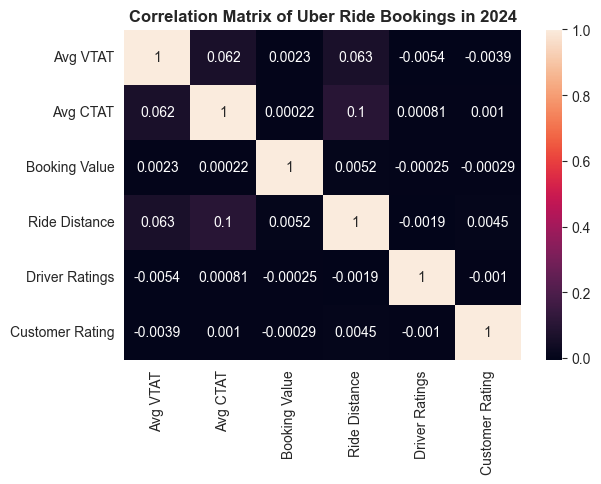

In [76]:
sns.heatmap(
    data=uber_df[num_cols].corr(),
    annot=True,
    fmt='.2g'
)
plt.tight_layout()
plt.title('Correlation Matrix of Uber Ride Bookings in 2024', fontweight='bold')
plt.show()

Based on the correlation matrix above, the **highest correlation coefficient was observed between the variables 'Avg CTAT' and 'Ride Distance'**, with a value of **0.1**. However, this value still indicated only a **weak correlation** between the two variables.

***

# 5. Conclusions & Recommendations

## 5.1. Conclusions

- **Most customers spent around 15-45 minutes waiting** on average, which may reduce satisfaction at rush hours.
- **Approximately 1 of 5 orders were cancelled by drivers**, which is relatively high.
- **Only 30% of all trips gained driver ratings of 4.5 and above**, which is relatively low because many platforms expect driver ratings to be above 4.6.
- **Unified Payments Interface (UPI) and Cash were payment methods that customers used most**, indicating that these were perceived as the most convenient options.
- 3 vehicle types: **Auto, Go Mini, and Go Sedan**, accounted for around 62.9% of all bookings in 2024, **making them the core business of Uber in India**

## 5.2. Recommendations

- **Provide a real-time traffic-based ETA** for more accurate estimation.
- **Implement pre-screening features to minimize the risk of cancellations due to health-related reasons**, as it accounted for 25% of the driver-cancelled rides.
- **Set a minimum rating threshold for drivers** (with the possibility of suspension if it fell below the limit) that may push their motivation to further improve their performance
- **Offer discounts, promotions, or loyalty rewards based on UPI and Cash** payment methods to boost transaction volume.
- **Improve driver quality & unit availability** for these 3 services, and **offer vouchers or discounts** to maintain large market share.